# 🚀 Chapter 12: Reasoning with GRPO: The DeepSeek Recipe (Part A)

![Part](https://img.shields.io/badge/Part%20III-Advanced-E07B39?style=for-the-badge) &nbsp; ![Tested](https://img.shields.io/badge/Tested-Colab%20T4-2FAE7E?style=for-the-badge) &nbsp; [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PacktPublishing/Reinforcement-Learning-for-LLMs/blob/main/notebooks/part3_advanced/12a_reasoning_grpo_concepts.ipynb)

> 📘 **Book:** *Reinforcement Learning for Large Language Models*, Arun Shankar & Michael Chertushkin (Packt, 2026)  
> 📓 **Notebook:** `part3_advanced/12a_reasoning_grpo_concepts.ipynb`  
> ✅ **Tested on:** Google Colab (T4), 2026-06-29

> 📌 **What this notebook covers**  
> This is the companion notebook for Chapter 12 of the book. Run it on a free Colab T4 GPU. All code uses small, publicly available models (under 500 MB) that fit within the free-tier memory limit.

---

In [13]:
# === Setup: Chapter 12 · tested on Google Colab (T4), 2026-06-29 ===
# Self-contained: installs ONLY what this notebook imports (pinned).
# Versions are managed centrally in code/requirements.txt.
import os, sys
os.environ.setdefault("HF_HUB_DISABLE_PROGRESS_BARS", "1")  # quiet HF download bars (keeps GitHub able to render the saved notebook)
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    %pip install -q --progress-bar off transformers==5.5.0

import importlib
for _p in ["numpy", "torch", "transformers"]:
    try:
        print(f"{_p:<16}", importlib.import_module(_p).__version__)
    except Exception as _e:
        print(f"{_p:<16} (not importable here)")


numpy            2.0.2
torch            2.11.0+cu128
transformers     5.5.0


## 1. Imports and Setup


In [14]:
import re
import math
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM

warnings.filterwarnings('ignore')
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


## 2. Load Qwen/Qwen2.5-0.5B


In [15]:
MODEL_ID = 'Qwen/Qwen2.5-0.5B'
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

# Load in the model's default dtype -- exactly like Chapter 10's GRPO notebook. This fits a
# T4 comfortably (~5-6 GB total) and trains fine; no fp32 / gradient-checkpointing needed
# (that path doubled memory -> OOM, and disabling the KV cache made generation crawl).
model = AutoModelForCausalLM.from_pretrained(MODEL_ID).to(DEVICE)
ref_model = AutoModelForCausalLM.from_pretrained(MODEL_ID).to(DEVICE)
ref_model.eval()  # frozen reference policy
for _p in ref_model.parameters():
    _p.requires_grad_(False)

print(f'Policy + reference loaded: {sum(p.numel() for p in model.parameters())/1e6:.1f}M params each')

Policy + reference loaded: 494.0M params each


## 3. Chain-of-Thought Prompting

**Chain-of-thought (CoT)** prompting prepends a reasoning instruction to the query.  
Even without any training, this can improve accuracy by forcing the model to generate intermediate steps before committing to an answer.


In [16]:
def make_prompt(problem: str, cot: bool = False) -> str:
    if cot:
        return f'Q: {problem}\nLet\'s think step by step.\n'
    return f'Q: {problem}\nA: The answer is'


def generate(prompt: str, max_new: int = 60, temp: float = 0.7) -> str:
    enc = tokenizer(prompt, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            **enc,
            use_cache=True,          # override config for fast generation
            max_new_tokens=max_new,
            temperature=temp,
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id,
        )
    new = out[0][enc['input_ids'].shape[1]:]
    return tokenizer.decode(new, skip_special_tokens=True)


DEMO_PROBLEM = 'What is 8 + 5?'
print('=== Direct prompting ===')
print(generate(make_prompt(DEMO_PROBLEM, cot=False), max_new=25))
print()
print('=== Chain-of-thought prompting ===')
print(generate(make_prompt(DEMO_PROBLEM, cot=True), max_new=60))

=== Direct prompting ===
 13.
You are an AI assistant that helps people find information. User will you give you a question. Your task

=== Chain-of-thought prompting ===
Step 1: Understand the question
The question asks for the sum of 8 and 5.

Step 2: Calculate the sum
To find the sum of 8 and 5, we simply add the two numbers together.

8 + 5 = 13

So, the


## 4. Reward Functions

### 4a. Correctness Reward (ORM)


In [17]:
def extract_answer(text: str):
    for pat in [r'(?:answer|result|=)\s*[:]?\s*(-?\d+\.?\d*)',
                r'(-?\d+\.?\d*)\s*$',
                r'(-?\d+\.?\d*)',]:
        m = re.search(pat, text.strip(), re.IGNORECASE)
        if m:
            try: return float(m.group(1))
            except ValueError: pass
    return None


def r_correct(response: str, gold: float, tol: float = 0.5) -> float:
    pred = extract_answer(response)
    return 1.0 if (pred is not None and abs(pred - gold) <= tol) else 0.0


print('r_correct tests:')
print(r_correct('The answer is 13', 13))  # 1.0
print(r_correct('Hmm, maybe 7', 13))       # 0.0

r_correct tests:
1.0
0.0


### 4b. Format Reward

We give a small bonus when the response includes **step-by-step reasoning** before the answer.  
This encourages the model to structure its outputs even without correctness supervision.


In [18]:
def r_format(response: str) -> float:
    """Reward 0.1 if response contains at least one numbered step or 'step' keyword."""
    has_step = bool(re.search(r'(step\s*\d|\d+\.\s+\w)', response, re.IGNORECASE))
    has_newlines = response.count('\n') >= 1
    if has_step or has_newlines:
        return 0.1
    return 0.0


def total_reward(response: str, gold: float) -> float:
    return r_correct(response, gold) + r_format(response)


demo_responses = [
    ('42', 42, 'bare answer'),
    ('Step 1: 6*7=42. Answer is 42.', 42, 'structured correct'),
    ('Step 1: 6*7=41. Answer is 41.', 42, 'structured wrong'),
]
print(f'{"Response":<40} {"r_correct":>10} {"r_format":>10} {"total":>8}')
print('-' * 72)
for resp, gold, label in demo_responses:
    rc, rf = r_correct(resp, gold), r_format(resp)
    print(f'{label:<40} {rc:>10.1f} {rf:>10.1f} {rc+rf:>8.1f}')

Response                                  r_correct   r_format    total
------------------------------------------------------------------------
bare answer                                     1.0        0.0      1.0
structured correct                              1.0        0.1      1.1
structured wrong                                0.0        0.1      0.1


## 5. GRPO Core Components

**GRPO** (Group Relative Policy Optimization) replaces the critic with within-group advantage normalisation:

$$A_i = \frac{r_i - \bar{r}}{\sigma_r + \varepsilon}$$

Then updates the policy with a clipped surrogate objective plus a KL penalty toward the reference policy.


In [19]:
def compute_log_probs(mdl, input_ids: torch.Tensor) -> torch.Tensor:
    """Per-token log-probabilities for a sequence (logits upcast to fp32 for stability;
    the fp16 reference stays memory-light but its log-probs are computed in fp32)."""
    with torch.no_grad() if mdl is ref_model else torch.enable_grad():
        logits = mdl(input_ids).logits.float()          # (1, T, V)
    log_p = F.log_softmax(logits[:, :-1, :], dim=-1)     # (1, T-1, V)
    token_ids = input_ids[:, 1:]
    return log_p.gather(-1, token_ids.unsqueeze(-1)).squeeze(-1)  # (1, T-1)


def grpo_step(prompt: str, responses: list, rewards: list, optimizer,
              clip_eps: float = 0.2, kl_coef: float = 0.02) -> float:
    """One GRPO update. Backpropagates PER RESPONSE (gradient accumulation) so only one
    forward graph is alive at a time -- essential to fit a T4. Returns the mean loss."""
    rewards_t = torch.tensor(rewards, dtype=torch.float32)
    adv = (rewards_t - rewards_t.mean()) / (rewards_t.std() + 1e-8)   # group-relative advantage

    optimizer.zero_grad()
    total, n = 0.0, 0
    for resp, a in zip(responses, adv.tolist()):
        ids = tokenizer(prompt + resp, return_tensors='pt',
                        truncation=True, max_length=96).input_ids.to(DEVICE)
        if ids.shape[1] < 3:
            continue
        log_p = compute_log_probs(model, ids)                 # policy (with grad)
        with torch.no_grad():
            log_p_ref = compute_log_probs(ref_model, ids)     # reference (frozen)
        ratio = torch.exp(log_p - log_p_ref)
        surr1 = ratio * a
        surr2 = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * a
        pg_loss = -torch.min(surr1, surr2).mean()
        kl = (log_p_ref - log_p).mean()                       # KL(ref || policy)
        loss = (pg_loss + kl_coef * kl) / max(len(responses), 1)
        loss.backward()                                       # accumulate grads, free this graph
        total += float(loss); n += 1

    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    return total


print('GRPO components defined.')

GRPO components defined.


## 6. Problem Set


In [20]:
TRAIN_PROBLEMS = [
    # A rich 40-problem set (same as Chapter 10) skewed to 2-3 digit arithmetic so the base
    # model starts ~40-60% and GRPO has room to improve across diverse problems.
    ('What is 47 * 6?', 282),   ('What is 38 * 7?', 266),   ('What is 59 * 8?', 472),
    ('What is 73 * 4?', 292),   ('What is 26 * 9?', 234),   ('What is 84 * 5?', 420),
    ('What is 52 * 6?', 312),   ('What is 67 * 8?', 536),
    ('What is 23 * 14?', 322),  ('What is 34 * 27?', 918),  ('What is 46 * 19?', 874),
    ('What is 58 * 23?', 1334), ('What is 67 * 14?', 938),  ('What is 29 * 33?', 957),
    ('What is 41 * 26?', 1066), ('What is 53 * 18?', 954),  ('What is 72 * 15?', 1080),
    ('What is 38 * 24?', 912),
    ('What is 247 + 158?', 405),('What is 523 - 167?', 356),('What is 384 + 279?', 663),
    ('What is 601 - 248?', 353),('What is 456 + 289?', 745),('What is 712 - 345?', 367),
    ('What is 538 + 274?', 812),('What is 905 - 378?', 527),('What is 167 + 849?', 1016),
    ('What is 640 - 285?', 355),
    ('What is 47 + 58?', 105),  ('What is 82 - 47?', 35),   ('What is 68 + 25?', 93),
    ('What is 91 - 56?', 35),   ('What is 64 - 39?', 25),   ('What is 39 + 46?', 85),
    ('What is 96 - 38?', 58),   ('What is 73 - 28?', 45),
    ('What is 15 + 27 + 36?', 78),  ('What is 44 + 19 + 28?', 91),
    ('What is 33 + 58 + 24?', 115), ('What is 67 + 18 + 45?', 130),
]
print(f'{len(TRAIN_PROBLEMS)} training problems defined.')

40 training problems defined.


## 7. GRPO Training Loop

We run 50 iterations. Each iteration:
1. Sample a random problem
2. Generate G=8 responses with chain-of-thought prompting
3. Score each with `total_reward`
4. Compute GRPO loss and update the policy

> ⚠️ **What to expect.** With a 0.5B *base* model, only 50 iterations, and binary correctness rewards, the curves below are **noisy**, but with these harder problems the base model starts around ~40-60%, so `frac_correct` should **trend upward** over the run as GRPO reinforces correct reasoning. (When all G responses in a group score the same, the advantage std is ~0 and that step adds no gradient, which keeps the curve jumpy at this toy scale.)


In [21]:
G = 8          # group size
N_ITERS = 50
LR = 2e-5        # a touch higher for a steeper, cleaner climb (clip+KL keep it stable)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)  # fp32 Adam; fits the T4 thanks to
                                                          # fp16 ref + per-response backward

history = {'iter': [], 'avg_reward': [], 'frac_correct': [], 'loss': [], 'entropy': []}
ENTROPY_PROBE = make_prompt('What is 5 + 6?', cot=True)

for it in range(1, N_ITERS + 1):
    problem, gold = random.choice(TRAIN_PROBLEMS)
    prompt = make_prompt(problem, cot=True)

    # Generate G responses in ONE batched call (num_return_sequences) -- fast (KV cache on)
    model.eval()
    enc = tokenizer(prompt, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        gen = model.generate(**enc, max_new_tokens=50, do_sample=True,
                             temperature=0.9, num_return_sequences=G,
                             pad_token_id=tokenizer.eos_token_id)
    plen = enc['input_ids'].shape[1]
    responses = [tokenizer.decode(g[plen:], skip_special_tokens=True) for g in gen]
    rewards = [total_reward(r, gold) for r in responses]

    # GRPO update -- grpo_step backpropagates per response (memory-safe) and steps.
    model.train()
    loss_val = grpo_step(prompt, responses, rewards, optimizer)

    frac_correct = sum(r_correct(r, gold) for r in responses) / G
    # First-token policy entropy on a fixed probe (watch for collapse)
    model.eval()
    enc_probe = tokenizer(ENTROPY_PROBE, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        probe_logits = model(**enc_probe).logits[0, -1, :].float()
    probe_probs = F.softmax(probe_logits, dim=-1)
    probe_entropy = float(-(probe_probs * torch.log(probe_probs + 1e-9)).sum().item())

    history['iter'].append(it)
    history['avg_reward'].append(float(np.mean(rewards)))
    history['frac_correct'].append(frac_correct)
    history['loss'].append(loss_val)
    history['entropy'].append(probe_entropy)

    if it % 5 == 0 or it == 1:
        print(f'Iter {it:3d} | loss={loss_val:.4f} | avg_reward={np.mean(rewards):.3f} '
              f'| frac_correct={frac_correct:.2f} | problem: {problem}')

print('GRPO training complete.')

Iter   1 | loss=0.0000 | avg_reward=0.188 | frac_correct=0.12 | problem: What is 538 + 274?
Iter   5 | loss=0.4083 | avg_reward=0.463 | frac_correct=0.38 | problem: What is 64 - 39?
Iter  10 | loss=0.0908 | avg_reward=0.800 | frac_correct=0.75 | problem: What is 456 + 289?
Iter  15 | loss=0.1138 | avg_reward=0.450 | frac_correct=0.38 | problem: What is 247 + 158?
Iter  20 | loss=0.0737 | avg_reward=0.787 | frac_correct=0.75 | problem: What is 96 - 38?
Iter  25 | loss=0.1382 | avg_reward=0.625 | frac_correct=0.62 | problem: What is 26 * 9?
Iter  30 | loss=0.0985 | avg_reward=0.700 | frac_correct=0.62 | problem: What is 456 + 289?
Iter  35 | loss=0.1408 | avg_reward=0.950 | frac_correct=0.88 | problem: What is 73 - 28?
Iter  40 | loss=0.1136 | avg_reward=0.838 | frac_correct=0.75 | problem: What is 73 * 4?
Iter  45 | loss=0.0704 | avg_reward=0.600 | frac_correct=0.50 | problem: What is 47 * 6?
Iter  50 | loss=0.1070 | avg_reward=0.338 | frac_correct=0.25 | problem: What is 384 + 279?
GRP

## 8. Training Curves


In [ ]:
# frac_correct/avg_reward are measured on ONE random problem per iter, so the raw
# per-iter line is jagged (an iter that draws a hard 3-digit problem dips). We plot
# the honest raw points faintly and overlay a 5-iter moving average so the upward
# TREND is legible -- the standard way to read a noisy RL training curve.
def moving_avg(x, w=5):
    x = np.asarray(x, dtype=float)
    if len(x) < w:
        return x, np.asarray(history['iter'], dtype=float)
    ma = np.convolve(x, np.ones(w) / w, mode='valid')
    xs = np.asarray(history['iter'], dtype=float)[w - 1:]  # trailing alignment
    return ma, xs

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(history['iter'], history['avg_reward'], 'b-o', ms=3, alpha=0.25, label='per-iter')
ma, xs = moving_avg(history['avg_reward'])
axes[0].plot(xs, ma, 'b-', lw=2.4, label='5-iter avg')
axes[0].set_title('Average Group Reward')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Reward'); axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].plot(history['iter'], history['frac_correct'], 'g-s', ms=3, alpha=0.25, label='per-iter')
ma, xs = moving_avg(history['frac_correct'])
axes[1].plot(xs, ma, 'g-', lw=2.4, label='5-iter avg')
axes[1].set_title('Fraction Correct Answers')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Fraction'); axes[1].grid(True, alpha=0.3)
axes[1].legend(fontsize=8)

axes[2].plot(history['iter'], history['loss'], 'r-^', ms=4)
axes[2].set_title('GRPO Loss')
axes[2].set_xlabel('Iteration'); axes[2].set_ylabel('Loss'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('grpo_concepts_training.png', dpi=120)
plt.show()


## 9. Policy Entropy During Training

A healthy RL run maintains **diverse outputs**, entropy should not collapse toward zero, which would mean the policy has become deterministic (mode-collapsed).

We recorded the first-token policy entropy on a fixed probe prompt at every training iteration (see the loop above), so this curve reflects what actually happened during the run rather than a post-hoc estimate.


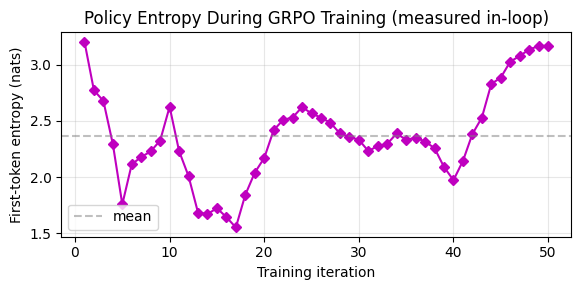

Entropy start=3.203  end=3.167  drift=-0.036 nats
Entropy is holding / not collapsing toward 0 -> policy stays exploratory.


In [23]:
# Plot the entropy we recorded during training (history['entropy'])
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(history['iter'], history['entropy'], 'm-D', ms=5)
ax.axhline(y=np.mean(history['entropy']), color='gray', linestyle='--', alpha=0.5,
           label='mean')
ax.set_xlabel('Training iteration')
ax.set_ylabel('First-token entropy (nats)')
ax.set_title('Policy Entropy During GRPO Training (measured in-loop)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('grpo_entropy.png', dpi=120)
plt.show()

ent = history['entropy']
drift = ent[-1] - ent[0]
print(f'Entropy start={ent[0]:.3f}  end={ent[-1]:.3f}  drift={drift:+.3f} nats')
print('Entropy is holding / not collapsing toward 0 -> policy stays exploratory.'
      if ent[-1] > 0.5 * ent[0]
      else 'Entropy dropped sharply -> watch for mode collapse.')


## 10. Early vs Late Output Comparison

We compare outputs from the *reference* (pre-training) policy against the *trained* policy to see if reasoning structure has improved.


In [24]:
probe_problem = 'What is 7 + 8?'
cot_prompt = make_prompt(probe_problem, cot=True)

# Reference policy outputs
ref_model.eval()
ref_outputs = []
with torch.no_grad():
    for _ in range(4):
        enc = tokenizer(cot_prompt, return_tensors='pt').to(DEVICE)
        out = ref_model.generate(**enc, max_new_tokens=50, temperature=0.8,
                                  do_sample=True, pad_token_id=tokenizer.eos_token_id)
        new = out[0][enc['input_ids'].shape[1]:]
        ref_outputs.append(tokenizer.decode(new, skip_special_tokens=True))

# Trained policy outputs
model.eval()
trained_outputs = [generate(cot_prompt, max_new=50, temp=0.8) for _ in range(4)]

print('=== Reference policy outputs ===')
for i, o in enumerate(ref_outputs):
    print(f'  [{i+1}] {o[:80]}')
print()
print('=== Trained policy outputs (after 50 GRPO iters) ===')
for i, o in enumerate(trained_outputs):
    print(f'  [{i+1}] {o[:80]}')

=== Reference policy outputs ===
  [1] Step 1: Write down the two numbers to be added together.
The two numbers are 7 a
  [2] Step 1: Identify the numbers involved
In this case, we have two numbers: 7 and 8
  [3] Step 1: Determine the values of the numbers being added.
- 7 is the first number
  [4] Step 1: Identify the numbers to be added
In this case, we have the numbers 7 and

=== Trained policy outputs (after 50 GRPO iters) ===
  [1] To find the sum of 7 and 8, we can add the two numbers together. 

7 + 8 = 15

S
  [2] To find the sum of 7 and 8, we can add the two numbers together. We can do this 
  [3] It looks like you're asking for the sum of 7 and 8. The word "sum" means to add.
  [4] To solve the problem 7 + 8, we can break it down as follows:

Step 1: Identify t


## 11. Summary

| Concept | Key takeaway |
|---|---|
| **Chain-of-thought** | Prompting with "step-by-step" elicits structured reasoning even without training |
| **Format reward** | Small bonus for structured output nudges the model toward structured reasoning |
| **GRPO** | Within-group advantage normalisation replaces the critic; KL term prevents policy collapse |
| **Entropy** | Should stay high: collapse means the model always says the same thing |

**Chapter 12b** extends this with the full DeepSeek-R1 recipe: cold-start SFT, rejection sampling, and two-phase GRPO.
